# 22 -- Gate 4: results assembly

Reads every manifest/CSV produced by nb14-21 and assembles dissertation-
ready tables and figures in one place, so writing doesn't mean manually
copying numbers out of nine different notebooks' outputs.

**Scope limit, stated up front**: this can only assemble what already
exists as a structured file (JSON/CSV). It CANNOT pull in the Gate 1
cohort decision (`pUNKH7L`/`pAFQRTM`/`pEAB9GS` keep/exclude reasoning) --
that lives in conversation history and diagnostic notebook output, not
in any exported manifest. Section 7 below is a clearly marked manual
placeholder for that, not an automated table.

No new analysis happens here -- if a number looks wrong, the bug is
upstream in whichever notebook produced it, not in this one.


In [1]:
from pathlib import Path
import json as _json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

%config InlineBackend.close_figures = False
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
DATA_DIR = MOD_DIR.parent
OUT_DIR = DATA_DIR / 'gate4_assembly'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)
print(f"Reading from {DATA_DIR.resolve()}, writing to {OUT_DIR.resolve()}")

MODALITIES = ['tap', 'gesture', 'motion', 'typing']


Reading from /Users/will/Documents/BBDC-Prototype-2-Research/data/processed, writing to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/gate4_assembly


## 1. Per-modality headline table (from nb14-17 manifests)

In [2]:
modality_rows = []
for m in MODALITIES:
    mdir = DATA_DIR / f'{m}_embedder'
    p = mdir / f'{m}_manifest.json'
    if not p.exists():
        print(f"WARNING: no manifest found for {m} at {p} -- skipping")
        continue
    man = _json.load(open(p))
    real = man.get('auc_real_fixed_at_k1_k10_k20', {})
    shuf = man.get('auc_shuffled_fixed_at_k1_k10_k20', {})
    modality_rows.append({
        'modality': m,
        'n_windows': man.get('n_windows'),
        'n_features': man.get('n_features'),
        'n_fixed_identities': man.get('n_fixed_identities'),
        'auc_k1': real.get('1'), 'auc_k10': real.get('10'), 'auc_k20': real.get('20'),
        'shuffled_auc_k20': shuf.get('20'),
        'gap_k20': (real.get('20') - shuf.get('20')) if real.get('20') and shuf.get('20') else None,
    })
modality_df = pd.DataFrame(modality_rows)
print(modality_df.to_string(index=False))
modality_df.to_csv(OUT_DIR / 'table1_per_modality_headline.csv', index=False)


modality  n_windows  n_features  n_fixed_identities  auc_k1  auc_k10  auc_k20  shuffled_auc_k20  gap_k20
     tap       3324          97                   8   0.851    0.924    0.958             0.557    0.401
 gesture       3324          56                   8   0.795    0.879    0.908             0.515    0.393
  motion       3291          26                   9   0.790    0.852    0.891             0.471    0.420
  typing        684         110                   1   0.849    0.989    1.000             0.633    0.367


## 2. Fusion sweep headline (from nb18)

In [3]:
fusion_dir = DATA_DIR / 'fusion_evaluation'
fusion_headline_path = fusion_dir / 'fusion_headline_k20.csv'
if fusion_headline_path.exists():
    fusion_headline = pd.read_csv(fusion_headline_path)
    print("Fusion sweep, k=20, fixed_across_k, ranked by AUC:")
    print(fusion_headline.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
    fusion_headline.to_csv(OUT_DIR / 'table2_fusion_headline.csv', index=False)
else:
    print(f"WARNING: {fusion_headline_path} not found -- re-run nb18 through the sweep section first")
    fusion_headline = pd.DataFrame()

fusion_manifest_path = fusion_dir / 'fusion_manifest.json'
if fusion_manifest_path.exists():
    fusion_man = _json.load(open(fusion_manifest_path))
    print()
    print("Best fusion config:", fusion_man.get('best_config_at_k20'))
    print("Original baseline citation:", fusion_man.get('original_baseline_citation'))


Fusion sweep, k=20, fixed_across_k, ranked by AUC:
 k   identity_set  n_probe_identities  n_trust_windows  median_span_s   auc   eer  far_at_10pct_frr              combo weight_scheme
20 fixed_across_k                   8              132        157.500 0.970 0.066             0.063         motion+tap       dynamic
20 fixed_across_k                   8              132        157.500 0.970 0.066             0.063         motion+tap         equal
20 fixed_across_k                   8              132        157.500 0.970 0.066             0.063         motion+tap         fixed
20 fixed_across_k                   8              132        157.500 0.967 0.104             0.118 gesture+motion+tap         fixed
20 fixed_across_k                   8              132        157.500 0.967 0.107             0.123 gesture+motion+tap       dynamic
20 fixed_across_k                   8              132        157.500 0.967 0.107             0.123 gesture+motion+tap         equal
20 fixed_across_k 

## 3. Identification and confusion matrix (from nb18 Section 13)

In [4]:
id_acc_path = fusion_dir / 'identification_accuracy.csv'
conf_matrix_path = fusion_dir / 'identification_confusion_matrix.csv'

if id_acc_path.exists():
    id_acc = pd.read_csv(id_acc_path)
    print("Closed-set identification accuracy:")
    print(id_acc.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
    id_acc.to_csv(OUT_DIR / 'table3_identification_accuracy.csv', index=False)
else:
    print(f"WARNING: {id_acc_path} not found")
    id_acc = pd.DataFrame()

if conf_matrix_path.exists():
    conf_matrix = pd.read_csv(conf_matrix_path, index_col=0)
    print()
    print("Confusion matrix available -- see table4_confusion_matrix.csv")
    conf_matrix.to_csv(OUT_DIR / 'table4_confusion_matrix.csv')


Closed-set identification accuracy:
 k  n_trust_windows  n_candidates  rank1_accuracy  rank3_accuracy  chance_rank1
 1              284            12           0.486           0.768         0.083
 2              276            12           0.536           0.819         0.083
 3              268            12           0.556           0.836         0.083
 5              252            12           0.567           0.845         0.083
 8              228            12           0.535           0.904         0.083
10              212            12           0.509           0.896         0.083
15              172            12           0.512           0.953         0.083
20              132            12           0.530           0.955         0.083

Confusion matrix available -- see table4_confusion_matrix.csv


## 4. Hijack detection summary (from nb19)

In [ ]:
hijack_manifest_path = DATA_DIR / 'hijack_evaluation' / 'hijack_manifest.json'
if hijack_manifest_path.exists():
    hijack_man = _json.load(open(hijack_manifest_path))
    print("Hijack detection summary:")
    for k, v in hijack_man.items():
        print(f"  {k}: {v}")
    pd.DataFrame([hijack_man]).to_csv(OUT_DIR / 'table5_hijack_summary.csv', index=False)
else:
    print(f"WARNING: {hijack_manifest_path} not found")


Hijack detection summary:
  generated_at_utc: 2026-09-05T08:23:49.135096+00:00
  modalities_used: ['tap', 'gesture', 'motion']
  detection_params: {'ROLL_W': 5, 'DETECT_SIGMA': 3.0, 'DEBOUNCE_N': 5, 'CALIBRATION_FRACTION': 0.5, 'split_fraction': 0.5}
  n_hijack_pairs: 132
  detection_rate: 0.9696969696969697
  n_controls: 12
  false_positive_rate: 0.3333333333333333
  median_windows_to_detect: 0.0
  span_s_per_window: 7.5


## 5. Stress test summary (from nb20)

In [ ]:
stress_manifest_path = DATA_DIR / 'stress_tests' / 'stress_test_manifest.json'
if stress_manifest_path.exists():
    stress_man = _json.load(open(stress_manifest_path))
    print("Stress test summary:")
    print(f"  A. Pace permutation: baseline={stress_man['test_a_pace_permutation']['baseline_auc']:.3f}, "
          f"shuffled={stress_man['test_a_pace_permutation']['pace_shuffled_auc']:.3f}")
    print(f"  B. Gradual hijack: {stress_man['test_b_gradual_hijack']['detection_rate']:.1%} detected "
          f"(n={stress_man['test_b_gradual_hijack']['n_evaluable']})")
    print(f"  C. Modality dropout: see table6_stress_dropout.csv")
    print(f"  D. Enrollment ablation: see table7_stress_enrollment.csv")
    print(f"  E. Replay sanity check: AUC={stress_man['test_e_replay_sanity_check']['auc']:.3f}")
    pd.DataFrame(stress_man['test_c_modality_dropout']).to_csv(OUT_DIR / 'table6_stress_dropout.csv', index=False)
    pd.DataFrame(stress_man['test_d_enrollment_ablation']).to_csv(OUT_DIR / 'table7_stress_enrollment.csv', index=False)
else:
    print(f"WARNING: {stress_manifest_path} not found")


Stress test summary:
  A. Pace permutation: baseline=0.897, shuffled=0.885
  B. Gradual hijack: 98.5% detected (n=66)
  C. Modality dropout: see table6_stress_dropout.csv
  D. Enrollment ablation: see table7_stress_enrollment.csv
  E. Replay sanity check: AUC=0.947


## 6. Gate 3 device evaluation summary (from nb21)

In [ ]:
gate3_manifest_path = DATA_DIR / 'gate3_device_evaluation' / 'gate3_manifest.json'
if gate3_manifest_path.exists():
    gate3_man = _json.load(open(gate3_manifest_path))
    print("Gate 3 conclusion:", gate3_man.get('conclusion'))
    print()
    print("Device group results:")
    print(pd.DataFrame(gate3_man['device_group_results']).to_string(index=False))
    pd.DataFrame(gate3_man['device_group_results']).to_csv(OUT_DIR / 'table8_gate3_device_groups.csv', index=False)
else:
    print(f"WARNING: {gate3_manifest_path} not found -- run nb21 first")


Gate 3 conclusion: inconclusive on device leakage (confounded by candidate-pool size); surfaced cohort-wide pace/ability limitation instead

Device group results:
     device_group  n_identities      auc      eer
iphone_13_13_mini             2 0.250000 0.500000
   iphone_16_plus             3 1.000000 0.000000
       iphone_17e             2      NaN      NaN
     older_iphone             5 0.777778 0.166667


## 7. Gate 1 cohort decision

The shift magnitudes and per-modality ranks below are now pulled
automatically from nb13's export cell (added specifically so this
section didn't have to stay a manual placeholder). The one thing that
STILL can't be automated is the actual keep/exclude/case-study VERDICT
itself -- that's a judgement call, not a computed number. Fill in the
`verdict` column by hand once decided.


In [ ]:
anom_dir = DATA_DIR / 'anomalous_diagnostic'
FLAGGED = ['pUNKH7L', 'pAFQRTM', 'pEAB9GS']
REASONS = {
    'pUNKH7L': 'thin low-activity probe session, confirmed via task-completion validity check',
    'pAFQRTM': 'documented one-handed to two-handed grip change (self-reported ctxHandUse)',
    'pEAB9GS': 'full cross-modal inversion, no matching self-report; ruled out device/session/test-account explanations',
}

shift_mag_path = anom_dir / 'all_identities_shift_magnitude.csv'
if shift_mag_path.exists():
    shift_mag = pd.read_csv(shift_mag_path).set_index('participantId')['shift_magnitude']
    print(f"Loaded shift magnitudes for {len(shift_mag)} identities from nb13's export -- "
          f"real numbers, not hardcoded.")
else:
    shift_mag = pd.Series(dtype=float)
    print(f"WARNING: {shift_mag_path} not found -- run nb13's export cell for at least one "
          f"participant first (any run exports the full list). Falling back to no shift-magnitude data.")

rows = []
for pid in FLAGGED:
    row = {'participantId': pid,
           'shift_magnitude': float(shift_mag.get(pid, float('nan'))),
           'verdict': 'TODO', 'reason': REASONS[pid]}
    man_path = anom_dir / f'{pid}_manifest.json'
    if man_path.exists():
        man = _json.load(open(man_path))
        row['own_rank_tap'] = man['own_rank_by_modality'].get('tap')
        row['own_rank_gesture'] = man['own_rank_by_modality'].get('gesture')
        row['own_rank_motion'] = man['own_rank_by_modality'].get('motion')
    rows.append(row)

cohort_decision = pd.DataFrame(rows)
print(cohort_decision.to_string(index=False))
print()
print("Replace 'TODO' with keep / exclude / case-study once decided, then re-save.")
cohort_decision.to_csv(OUT_DIR / 'table9_gate1_cohort_decision.csv', index=False)


Loaded shift magnitudes for 12 identities from nb13's export -- real numbers, not hardcoded.
participantId  shift_magnitude verdict                                                                                                  reason  own_rank_tap  own_rank_gesture  own_rank_motion
      pUNKH7L         6.859643    TODO                           thin low-activity probe session, confirmed via task-completion validity check             4                 2                7
      pAFQRTM         9.402340    TODO                              documented one-handed to two-handed grip change (self-reported ctxHandUse)             4                 3                8
      pEAB9GS        10.172464    TODO full cross-modal inversion, no matching self-report; ruled out device/session/test-account explanations            12                10               11

Replace 'TODO' with keep / exclude / case-study once decided, then re-save.


## 8. Summary figure: AUC vs k, all four modalities + best fusion

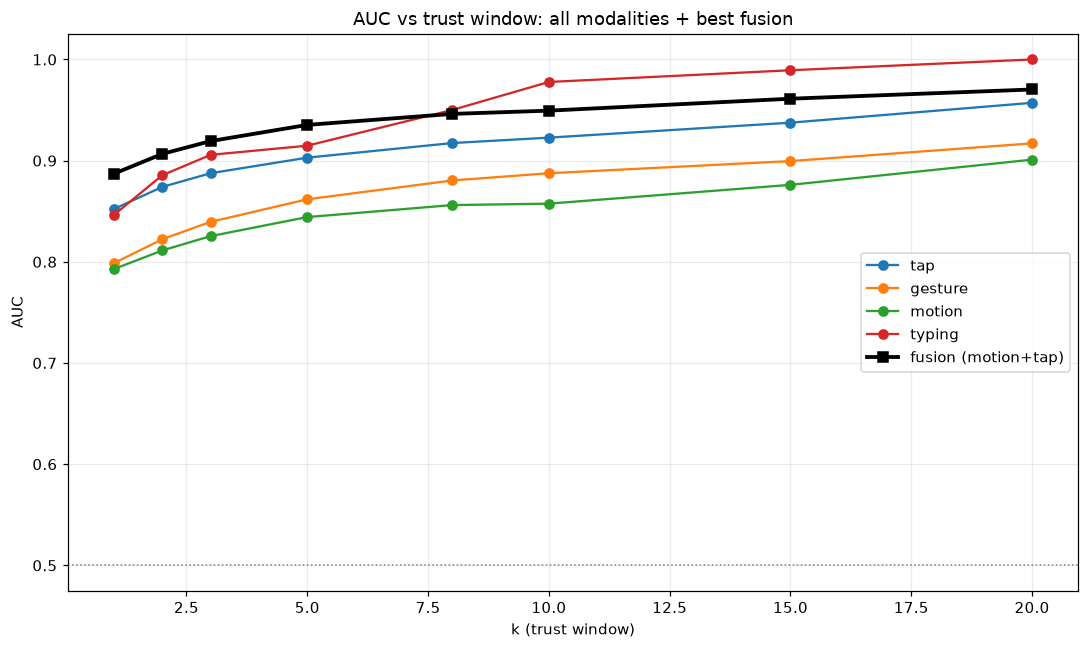

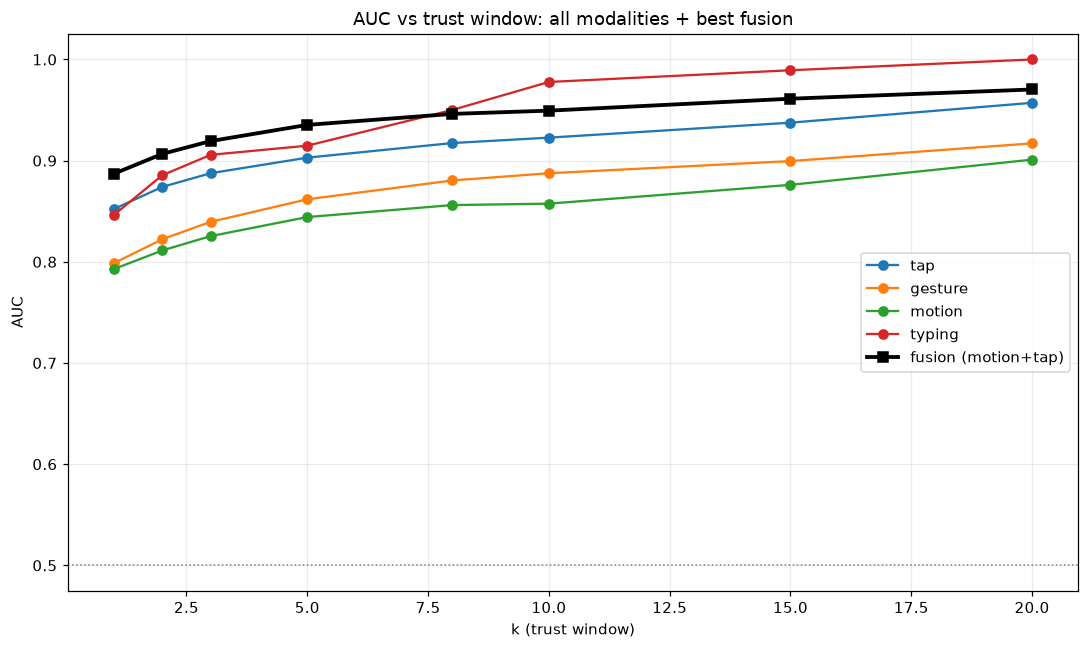

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for m in MODALITIES:
    p = DATA_DIR / f'{m}_embedder' / f'{m}_trained_vs_baseline.csv'
    if not p.exists():
        continue
    df = pd.read_csv(p)
    sub = df[df['identity_set'] == 'fixed_across_k']
    if sub.empty:
        sub = df[df['identity_set'] == 'all_available']
    ax.plot(sub['k'], sub['auc'], marker='o', label=m)

if not fusion_headline.empty and 'combo' in fusion_headline.columns:
    best_combo_rows = fusion_headline[fusion_headline['combo'] == fusion_headline.iloc[0]['combo']]
    fusion_sweep_path = fusion_dir / 'fusion_sweep_full.csv'
    if fusion_sweep_path.exists():
        sweep = pd.read_csv(fusion_sweep_path)
        best_combo = fusion_headline.iloc[0]['combo']
        best_scheme = fusion_headline.iloc[0]['weight_scheme']
        sub = sweep[(sweep['combo']==best_combo) & (sweep['weight_scheme']==best_scheme) &
                     (sweep['identity_set']=='fixed_across_k')].sort_values('k')
        ax.plot(sub['k'], sub['auc'], marker='s', lw=2.5, color='black',
                label=f'fusion ({best_combo})')

ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('k (trust window)'); ax.set_ylabel('AUC')
ax.set_title('AUC vs trust window: all modalities + best fusion')
ax.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'summary_auc_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Index of everything assembled

In [ ]:
print("Files written to", OUT_DIR.resolve(), ":")
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f"  {p.relative_to(OUT_DIR)}")

print()
print("Still needed before this is dissertation-ready:")
print("  - Fill in Section 7's TODO verdicts once the Gate 1 cohort decision is finalised")
print("  - Confirm the window-length/stride figure (15s/7.5s, empirically confirmed in nb18)")
print("    is written into subsec:p2-pipeline")
print("  - Nothing else in this notebook required manual entry -- everything else pulled")
print("    directly from existing manifests/CSVs")


Files written to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/gate4_assembly :
  plots/summary_auc_vs_k.png
  table1_per_modality_headline.csv
  table2_fusion_headline.csv
  table3_identification_accuracy.csv
  table4_confusion_matrix.csv
  table5_hijack_summary.csv
  table6_stress_dropout.csv
  table7_stress_enrollment.csv
  table8_gate3_device_groups.csv
  table9_gate1_cohort_decision.csv

Still needed before this is dissertation-ready:
  - Fill in Section 7's TODO verdicts once the Gate 1 cohort decision is finalised
  - Confirm the window-length/stride figure (15s/7.5s, empirically confirmed in nb18)
    is written into subsec:p2-pipeline
  - Nothing else in this notebook required manual entry -- everything else pulled
    directly from existing manifests/CSVs
